https://www.learnpytorch.io/

https://github.com/mrdbourke/pytorch-deep-learning

## **Todos**


* Gradient descent - https://youtu.be/IHZwWFHWa-w

* Backpropagation - https://youtu.be/Ilg3gGewQ5U


* Zero grad of the optimizer
```
optimizer.zero_grad()
```

* Loss backwards =>
```
loss.backward()
```

* Progress the optimizer
```
optimizer.step()
```

* Why unsqueeze(dim=1)
```
X = torch.arange(0.0, 1.0, 0.01).unsqueeze(dim=1)
```

# PyTorch Workflow Fundamentals
<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01_a_pytorch_workflow.png">

https://www.learnpytorch.io/01_pytorch_workflow/

## **Imports**

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

from sklearn.model_selection import train_test_split

torch.__version__

'2.6.0+cu124'

In [21]:
if torch.cuda.is_available():
  device = "cuda"
elif torch.mps.is_available():
  device = "mps"
else:
  device = "cpu"

device

'cpu'

## **Load and Prepare Dataset**

### Create Data

In [22]:
import torch
import random

# Create known parameters
weight = 0.7
bias = 0.3

# Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)

# Add random noise to y
torch.manual_seed(42)
noise = torch.randn_like(X) * 0.05  # std deviation of 0.1
y = weight * X + bias + noise

# Show first 10 samples
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3963],
         [0.3884],
         [0.3730],
         [0.2367],
         [0.3899],
         [0.3083],
         [0.3818],
         [0.3178],
         [0.3744],
         [0.5084]]))

In [23]:
len(X), len(y)

(50, 50)

### Visualize Data

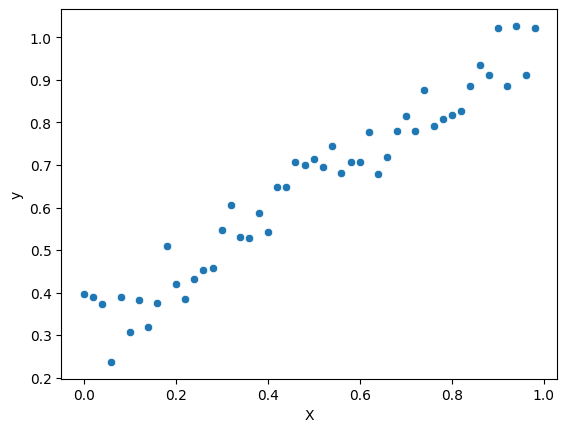

In [24]:
sns.scatterplot(x=X.squeeze(1), y=y.squeeze(1))
plt.xlabel("X")
plt.ylabel("y")
plt.show()

### Split data into training and test sets

<table>
<thead>
<tr>
<th>Split</th>
<th>Purpose</th>
<th>Amount of total data</th>
<th>How often is it used?</th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>Training set</strong></td>
<td>The model learns from this data (like the course materials you study during the semester).</td>
<td>~60-80%</td>
<td>Always</td>
</tr>
<tr>
<td><strong>Validation set</strong></td>
<td>The model gets tuned on this data (like the practice exam you take before the final exam).</td>
<td>~10-20%</td>
<td>Often but not always</td>
</tr>
<tr>
<td><strong>Testing set</strong></td>
<td>The model gets evaluated on this data to test what it has learned (like the final exam you take at the end of the semester).</td>
<td>~10-20%</td>
<td>Always</td>
</tr>
</tbody>
</table>

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
X_test.shape, y_test.shape

(torch.Size([10, 1]), torch.Size([10, 1]))

In [27]:
X_train.shape, y_train.shape

(torch.Size([40, 1]), torch.Size([40, 1]))

### Visualize Function

In [28]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     preds_data=None, # x
                     preds_labels=None, # y
                     predictions=None, # y^
                     scatter_size=16,
                     figsize=(10, 7)):
    """
    Plots training data, test data and compares predictions.

    For prediction visualization you should pass preds_data, preds_labels and predictions
    """
    with torch.inference_mode():
      plt.figure(figsize=figsize)

      # Plot training data in blue
      plt.scatter(x=train_data, y=train_labels, c="b", s=scatter_size, label="Training data")

      # Plot test data in green
      plt.scatter(x=test_data, y=test_labels, c="g", s=scatter_size, label="Testing data")

      if preds_labels is not None and preds_data is not None and predictions is not None:
        # Create pair of points
        true_pairs = list(zip(preds_data.squeeze().detach(), preds_labels.squeeze().detach()))
        pred_pairs = list(zip(preds_data.squeeze().detach(), predictions.squeeze().detach()))
        for (x1, y1), (x2, y2) in zip(pred_pairs, true_pairs):
            # It draws a line from (x1, y1) → (x2, y2)
            plt.plot([x1, x2], [y1, y2], color='gray', linestyle='--')  # Line from prediction to actual

        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(x=preds_data, y=predictions, c="r", s=scatter_size, label="Predictions")

      # Labels and legend
      plt.xlabel("X", fontsize=12)
      plt.ylabel("Y", fontsize=12)
      plt.title("Training, Testing & Prediction Visualization", fontsize=14)
      plt.legend(prop={"size": 12})
      plt.grid(True, linestyle='--', alpha=0.5)
      plt.show()

In [29]:
# plot_predictions()

## **Build Model**

**PyTorch model building essentials**

| PyTorch module     | What does it do?                                                                                                                                                                                                                              |
|--------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| torch.nn           | Contains all of the building blocks for computational graphs (essentially a series of computations executed in a particular way).                                                                                                             |
| torch.nn.Parameter | Stores tensors that can be used with nn.Module. If requires_grad=True gradients (used for updating model parameters via gradient descent)  are calculated automatically, this is often referred to as "autograd".                             |
| torch.nn.Module    | The base class for all neural network modules, all the building blocks for neural networks are subclasses. If you're building a neural network in PyTorch, your models should subclass nn.Module. Requires a forward() method be implemented. |
| torch.optim        | Contains various optimization algorithms (these tell the model parameters stored in nn.Parameter how to best change to improve gradient descent and in turn reduce the loss).                                                                 |
| def forward()      | All nn.Module subclasses require a forward() method, this defines the computation that will take place on the data passed to the particular nn.Module (e.g. the linear regression formula above).                                             |


Almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)

The line super().__init__() in a class’s __init__ method is used to call the parent class’s constructor, ensuring that everything the parent class needs to initialize gets properly set up

Two main algorithms that our model and nn use to train:

* Gradient descent - https://youtu.be/IHZwWFHWa-w

* Backpropagation - https://youtu.be/Ilg3gGewQ5U


### Model

In [30]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        # In Python, super().__init__() is used within the __init__ method of a child class to call the __init__ method of its parent class.
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float),
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float),
                                requires_grad=True)

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

* **torch.rand()**: is for uniform random numbers in \([0,1)\).
* **torch.randn()**: is for random numbers from a standard normal distribution (mean 0, standard deviation 1)

### Checking the contents of a PyTorch model

In [31]:
# Disposable
torch.manual_seed(42)
torch.cuda.manual_seed(42)

In [32]:
lr_model = LinearRegressionModel()

In [33]:
# list(lr_model.parameters())
# lr_model.weights, lr_model.bias
lr_model.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making predictions using torch.inference_mode()

`torch.inference_mode()` means:

>Just make predictions. Don’t learn, don’t remember anything, and don’t waste time with gradients.

In [34]:
# Make predictions with model
with torch.inference_mode():
    y_preds = lr_model(X_test)
    y_preds_train = lr_model(X_train)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

In [35]:
y_preds, y_test

(tensor([[0.2163],
         [0.3914],
         [0.3308],
         [0.4318],
         [0.2433],
         [0.4520],
         [0.3039],
         [0.2972],
         [0.3443],
         [0.2568]]),
 tensor([[0.4540],
         [0.8092],
         [0.7074],
         [1.0222],
         [0.5300],
         [0.9119],
         [0.6945],
         [0.7148],
         [0.6788],
         [0.5880]]))

### Visualize The Predictions

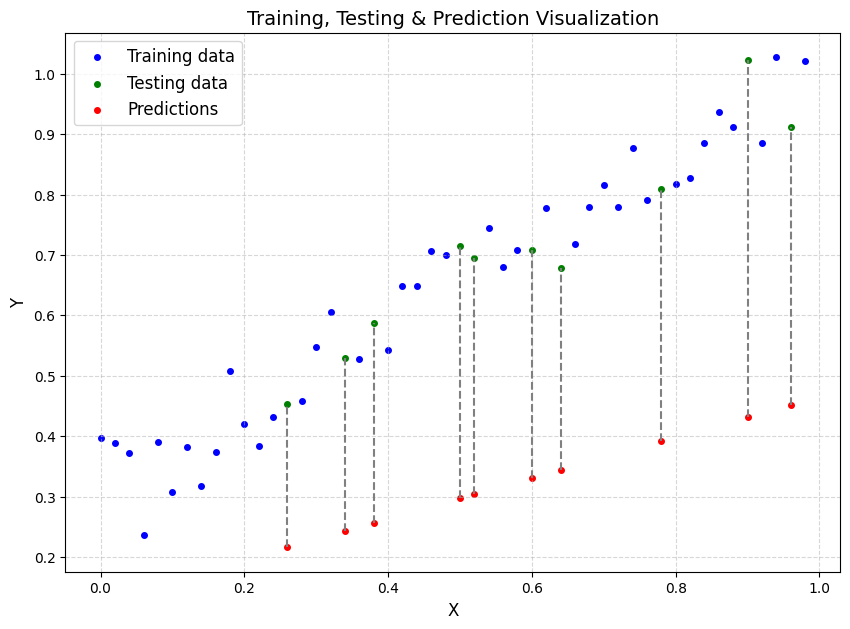

In [36]:
plot_predictions(preds_data=X_test, preds_labels=y_test, predictions=y_preds)

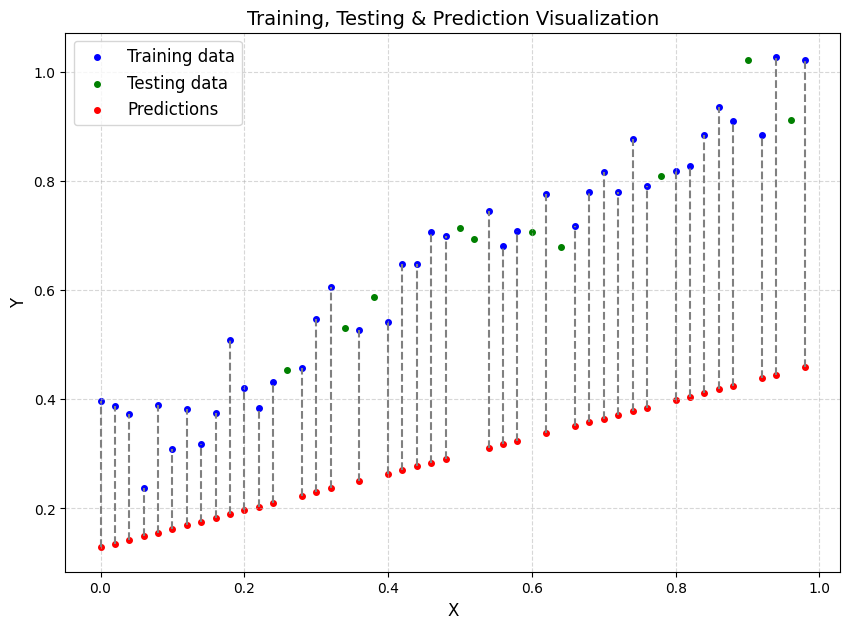

In [37]:
plot_predictions(preds_data=X_train, preds_labels=y_train, predictions=y_preds_train)

## **Train Models**

### Creating a loss function and optimizer in PyTorch


|Function|What does it do?|Where does it live in PyTorch?|Common values|
|:----|:----|:----|:----|
|**Loss function**|Measures how wrong your model's predictions (e.g. `y_preds`) are compared to the truth labels (e.g. `y_test`). Lower the better.|PyTorch has plenty of built-in loss functions in [`torch.nn`](https://pytorch.org/docs/stable/nn.html#loss-functions).|Mean absolute error (MAE) for regression problems ([`torch.nn.L1Loss()`](https://pytorch.org/docs/stable/generated/torch.nn.L1Loss.html)). Binary cross entropy for binary classification problems ([`torch.nn.BCELoss()`](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html)).|
|**Optimizer**|Tells your model how to update its internal parameters to best lower the loss.|You can find various optimization function implementations in [`torch.optim`](https://pytorch.org/docs/stable/optim.html).|Stochastic gradient descent ([`torch.optim.SGD()`](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html#torch.optim.SGD)). Adam optimizer ([`torch.optim.Adam()`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#torch.optim.Adam)).|


In [38]:
torch.manual_seed(42)
lr_model = LinearRegressionModel()

**lr vs momentum**

In the context of training neural networks, learning rate and momentum are two distinct but related concepts that influence how the model learns. The learning rate controls the step size when updating model weights based on the gradient, while momentum helps accelerate learning by incorporating past gradient information. Essentially, momentum acts as a "memory" of previous updates, allowing the optimization process to overcome local minima and converge faster, especially when the learning rate is small

Imagine a ball rolling down a hill. The learning rate is like the size of the steps you take when pushing the ball. Momentum is like the ball's tendency to keep rolling in the same direction it's already moving, even if there are small bumps or changes in the slope. By using both, you can help the ball (the optimization process) reach the bottom of the hill (the minimum error) more efficiently

In [39]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=lr_model.named_parameters(), lr=0.01, momentum=0)

<img src="https://www.jeremyjordan.me/content/images/2018/02/Screen-Shot-2018-02-24-at-11.47.09-AM.png">

### PyTorch training loop

**Train**
<table>
<thead>
<tr>
<th>Number</th>
<th>Step name</th>
<th>What does it do?</th>
<th>Code example</th>
</tr>
</thead>
<tbody>
<tr>
<td>1</td>
<td>Forward pass</td>
<td>The model goes through all of the training data once, performing its <code>forward()</code> function calculations.</td>
<td><code>model(x_train)</code></td>
</tr>
<tr>
<td>2</td>
<td>Calculate the loss</td>
<td>The model's outputs (predictions) are compared to the ground truth and evaluated to see how wrong they are.</td>
<td><code>loss = loss_fn(y_pred, y_train)</code></td>
</tr>
<tr>
<td>3</td>
<td>Zero gradients</td>
<td>The optimizers gradients are set to zero (they are accumulated by default) so they can be recalculated for the specific training step.</td>
<td><code>optimizer.zero_grad()</code></td>
</tr>
<tr>
<td>4</td>
<td>Perform backpropagation on the loss</td>
<td>Computes the gradient of the loss with respect for every model parameter to be updated  (each parameter with <code>requires_grad=True</code>). This is known as <strong>backpropagation</strong>, hence "backwards".</td>
<td><code>loss.backward()</code></td>
</tr>
<tr>
<td>5</td>
<td>Update the optimizer (<strong>gradient descent</strong>)</td>
<td>Update the parameters with <code>requires_grad=True</code> with respect to the loss gradients in order to improve them.</td>
<td><code>optimizer.step()</code></td>
</tr>
</tbody>
</table>

---
---

**Test**

<table>
<thead>
<tr>
<th>Number</th>
<th>Step name</th>
<th>What does it do?</th>
<th>Code example</th>
</tr>
</thead>
<tbody>
<tr>
<td>1</td>
<td>Forward pass</td>
<td>The model goes through all of the testing data once, performing its <code>forward()</code> function calculations.</td>
<td><code>model(x_test)</code></td>
</tr>
<tr>
<td>2</td>
<td>Calculate the loss</td>
<td>The model's outputs (predictions) are compared to the ground truth and evaluated to see how wrong they are.</td>
<td><code>loss = loss_fn(y_pred, y_test)</code></td>
</tr>
<tr>
<td>3</td>
<td>Calulate evaluation metrics (optional)</td>
<td>Alongside the loss value you may want to calculate other evaluation metrics such as accuracy on the test set.</td>
<td>Custom functions</td>
</tr>
</tbody>
</table>

In [40]:
# How many times the model will pass over the training data
epochs = 101
plot = False

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    lr_model.train()

    # 1. Forward pass on train data using the forward() method inside
    y_preds = lr_model(X_train)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_preds, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing
    lr_model.eval()

    with torch.inference_mode():
        # 1. Forward pass on test data
        test_preds = lr_model(X_test)

        # 2. Caculate loss on test data
        test_loss = loss_fn(test_preds, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

        # Print out what's happening
        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().cpu().numpy())
            test_loss_values.append(test_loss.detach().cpu().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

        # Plot
        if plot and epoch % 20 == 0:
            plot_predictions(preds_data=X_test, preds_labels=y_test, predictions=test_preds, figsize=(8, 4))


Epoch: 0 | MAE Train Loss: 0.34641844034194946 | MAE Test Loss: 0.3715662658214569 
Epoch: 10 | MAE Train Loss: 0.22599220275878906 | MAE Test Loss: 0.24523012340068817 
Epoch: 20 | MAE Train Loss: 0.1287827044725418 | MAE Test Loss: 0.1327877789735794 
Epoch: 30 | MAE Train Loss: 0.08341151475906372 | MAE Test Loss: 0.06926552206277847 
Epoch: 40 | MAE Train Loss: 0.06353960931301117 | MAE Test Loss: 0.04763760045170784 
Epoch: 50 | MAE Train Loss: 0.05832503363490105 | MAE Test Loss: 0.04445390775799751 
Epoch: 60 | MAE Train Loss: 0.056363217532634735 | MAE Test Loss: 0.04288170859217644 
Epoch: 70 | MAE Train Loss: 0.055081211030483246 | MAE Test Loss: 0.04169297218322754 
Epoch: 80 | MAE Train Loss: 0.053831495344638824 | MAE Test Loss: 0.040797602385282516 
Epoch: 90 | MAE Train Loss: 0.05290089175105095 | MAE Test Loss: 0.0404806025326252 
Epoch: 100 | MAE Train Loss: 0.05219664424657822 | MAE Test Loss: 0.04218399524688721 


### Train Process Function

| Expression              | Meaning                                |
| ----------------------- | -------------------------------------- |
| `tensor`                  | A PyTorch tensor that tracks gradients |
| `tensor.detach()`         | Same tensor, but **no gradients**      |


In [41]:
def train(lr_model: LinearRegressionModel,
          loss_fn: nn.L1Loss=None,
          optimizer: torch.optim.SGD=None,
          epochs: int=101,
          isPlot: bool=False
          ):

  """
  returning a list of list that contain epoch_count, train_loss_value and test_loss_value
  """

  # Create empty loss lists to track values
  train_loss_values = []
  test_loss_values = []
  epoch_count = []

  for epoch in range(epochs):
      ### Training
      # Put model in training mode (this is the default state of a model)
      lr_model.train()

      # 1. Forward pass on train data using the forward() method inside
      y_preds = lr_model(X_train)

      # 2. Calculate the loss (how different are our models predictions to the ground truth)
      loss = loss_fn(y_preds, y_train)

      # 3. Zero grad of the optimizer
      optimizer.zero_grad()

      # 4. Loss backwards
      loss.backward()

      # 5. Progress the optimizer
      optimizer.step()

      ### Testing
      lr_model.eval()

      with torch.inference_mode():
          # 1. Forward pass on test data
          test_preds = lr_model(X_test)

          # 2. Caculate loss on test data
          test_loss = loss_fn(test_preds, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

          # Print out what's happening
          if epoch % 10 == 0:
              epoch_count.append(epoch)
              train_loss_values.append(loss.detach().cpu().numpy())
              test_loss_values.append(test_loss.detach().cpu().numpy())
              print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

          # Plot
          if isPlot and epoch % 20 == 0:
              plot_predictions(preds_data=X_test, preds_labels=y_test, predictions=test_preds, figsize=(8, 4))

  return zip(epoch_count, train_loss_values, test_loss_values)

In [42]:
torch.manual_seed(42)
lr_model = LinearRegressionModel()
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=lr_model.named_parameters(), lr=0.01, momentum=0)

logs = train(lr_model=lr_model, loss_fn=loss_fn, optimizer=optimizer, isPlot=False, epochs=150)

Epoch: 0 | MAE Train Loss: 0.34641844034194946 | MAE Test Loss: 0.3715662658214569 
Epoch: 10 | MAE Train Loss: 0.22599220275878906 | MAE Test Loss: 0.24523012340068817 
Epoch: 20 | MAE Train Loss: 0.1287827044725418 | MAE Test Loss: 0.1327877789735794 
Epoch: 30 | MAE Train Loss: 0.08341151475906372 | MAE Test Loss: 0.06926552206277847 
Epoch: 40 | MAE Train Loss: 0.06353960931301117 | MAE Test Loss: 0.04763760045170784 
Epoch: 50 | MAE Train Loss: 0.05832503363490105 | MAE Test Loss: 0.04445390775799751 
Epoch: 60 | MAE Train Loss: 0.056363217532634735 | MAE Test Loss: 0.04288170859217644 
Epoch: 70 | MAE Train Loss: 0.055081211030483246 | MAE Test Loss: 0.04169297218322754 
Epoch: 80 | MAE Train Loss: 0.053831495344638824 | MAE Test Loss: 0.040797602385282516 
Epoch: 90 | MAE Train Loss: 0.05290089175105095 | MAE Test Loss: 0.0404806025326252 
Epoch: 100 | MAE Train Loss: 0.05219664424657822 | MAE Test Loss: 0.04218399524688721 
Epoch: 110 | MAE Train Loss: 0.05162300914525986 | MAE

In [43]:
lr_model.state_dict()

OrderedDict([('weights', tensor([0.6010])), ('bias', tensor([0.3598]))])

### Visualization

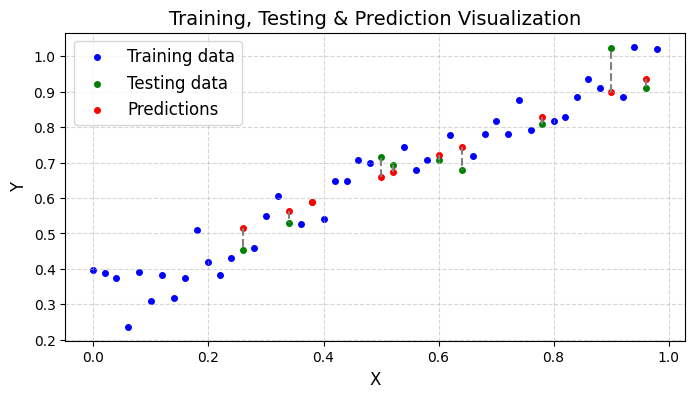

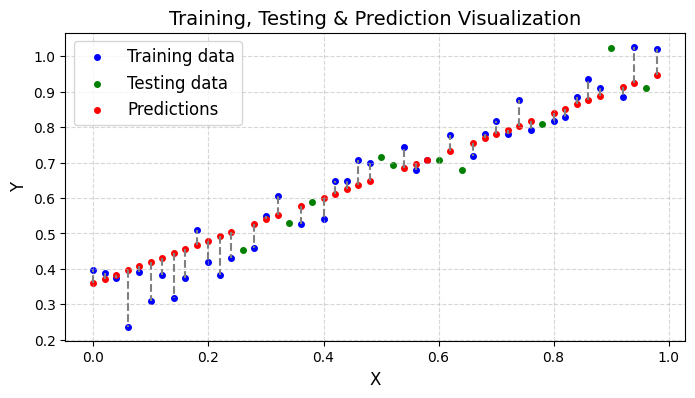

In [44]:
with torch.inference_mode():
  test_preds = lr_model(X_test)
  plot_predictions(preds_data=X_test, preds_labels=y_test, predictions=test_preds, figsize=(8, 4))

  train_preds = lr_model(X_train)
  plot_predictions(preds_data=X_train, preds_labels=y_train, predictions=train_preds, figsize=(8, 4))

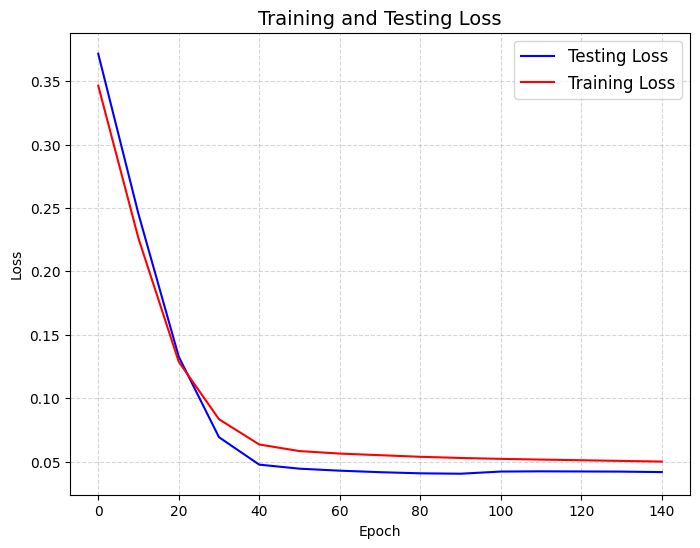

In [45]:
# Plot logs
plt.figure(figsize=(8, 6))
logs = np.array(list(logs))
plt.plot(logs[:, 0], logs[:, 2], color='b', label="Testing Loss")
plt.plot(logs[:, 0], logs[:, 1], color='r', label="Training Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Testing Loss", fontsize=14)
plt.legend(prop={"size": 12})
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## **Save & Load Model**

<div class="md-typeset__table"><table>
<thead>
<tr>
<th>PyTorch method</th>
<th>What does it do?</th>
</tr>
</thead>
<tbody>
<tr>
<td><a href="https://pytorch.org/docs/stable/torch.html?highlight=save#torch.save"><code>torch.save</code></a></td>
<td>Saves a serialized object to disk using Python's <a href="https://docs.python.org/3/library/pickle.html"><code>pickle</code></a> utility. Models, tensors and various other Python objects like dictionaries can be saved using <code>torch.save</code>.</td>
</tr>
<tr>
<td><a href="https://pytorch.org/docs/stable/torch.html?highlight=torch%20load#torch.load"><code>torch.load</code></a></td>
<td>Uses <code>pickle</code>'s unpickling features to deserialize and load pickled Python object files (like models, tensors or dictionaries) into memory. You can also set which device to load the object to (CPU, GPU etc).</td>
</tr>
<tr>
<td><a href="https://pytorch.org/docs/stable/generated/torch.nn.Module.html?highlight=load_state_dict#torch.nn.Module.load_state_dict"><code>torch.nn.Module.load_state_dict</code></a></td>
<td>Loads a model's parameter dictionary (<code>model.state_dict()</code>) using a saved <code>state_dict()</code> object.</td>
</tr>
</tbody>
</table></div>

### Save and Load Whole Model

In [46]:
torch.save(lr_model, "lr_model.pt")

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint.

  (1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.

  (2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL __main__.LinearRegressionModel was not an allowed global by default. Please use `torch.serialization.add_safe_globals([LinearRegressionModel])` or the `torch.serialization.safe_globals([LinearRegressionModel])` context manager to allowlist this global if you trust this class/function.

In [47]:
lr_model_temp = torch.load("lr_model.pt", weights_only=False)

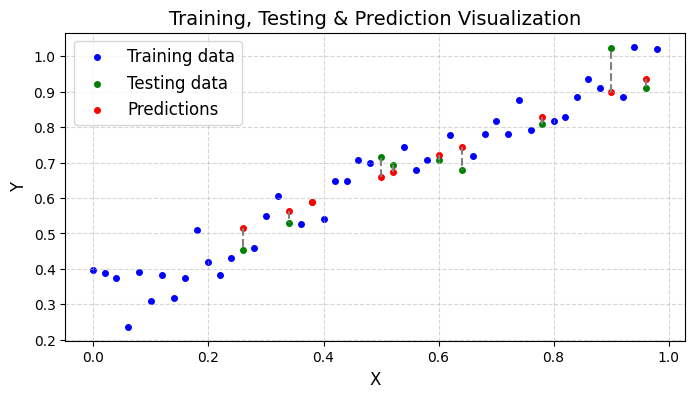

In [48]:
with torch.inference_mode():
    test_preds = lr_model_temp(X_test)

    plot_predictions(preds_data=X_test, preds_labels=y_test, predictions=test_preds, figsize=(8, 4))

### Save and Load State Dict

The recommended way for saving and loading a model for inference (making predictions) is by saving and loading a model's state_dict().

In [49]:
torch.save(lr_model.state_dict(), "lr_model_state_dict.pt")

In [50]:
state_dict = torch.load("lr_model_state_dict.pt")

In [51]:
state_dict

OrderedDict([('weights', tensor([0.6010])), ('bias', tensor([0.3598]))])

In [52]:
lr_model_temp = LinearRegressionModel()

In [53]:
lr_model_temp.load_state_dict(state_dict)

<All keys matched successfully>

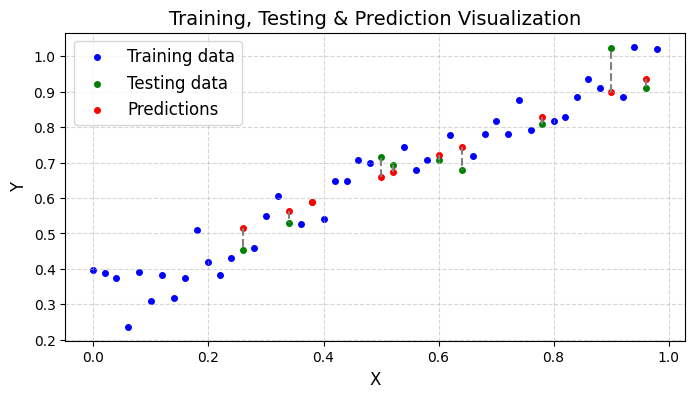

In [54]:
with torch.inference_mode():
    test_preds = lr_model_temp(X_test)

    plot_predictions(preds_data=X_test, preds_labels=y_test, predictions=test_preds, figsize=(8, 4))

## **Putting All Together**

### Import

In [1]:
import torch
from torch import nn

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

torch.__version__

'2.6.0+cu124'

### Constants

In [2]:
random_seed = 42

### Agnostic Device

In [3]:
if torch.cuda.is_available():
  device = "cuda"
elif torch.mps.is_available():
  device = "mps"
else:
  device = "cpu"

device

'cpu'

### Create Data

In [4]:
weights = 0.7
bias = 0.3

X = torch.arange(0.0, 1.0, 0.01).type(torch.float32).unsqueeze(dim=1)
torch.manual_seed(random_seed)
noises = torch.randn_like(X) * 0.05

y = weights * X + bias + noises

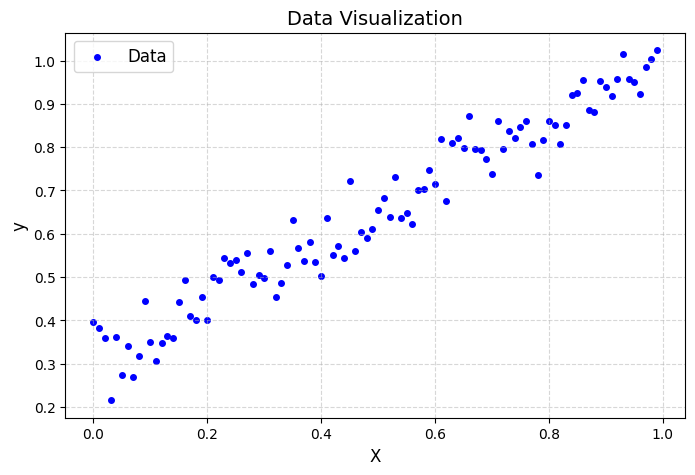

In [5]:
plt.figure(figsize=(8, 5))

plt.scatter(x=X, y=y, c="b", s=16, label="Data")

plt.xlabel("X", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("Data Visualization", fontsize=14)
plt.legend(prop={"size": 12})
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Split Train and Test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

Tensors Device

In [7]:
X_train = X_train.to(device)
X_test = X_test.to(device)

y_train = y_train.to(device)
y_test = y_test.to(device)

### Plot Fn

In [8]:
def plot_predictions_compact(train_data=X_train,
                             train_labels=y_train,
                             test_data=X_test,
                             test_labels=y_test,
                             predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    with torch.inference_mode():
      plt.figure(figsize=(8, 5))

      # Plot training data in blue
      plt.scatter(x=train_data.detach().cpu(), y=train_labels.detach().cpu(), c="b", s=16, label="Training data")

      # Plot test data in green
      plt.scatter(x=test_data.detach().cpu(), y=test_labels.detach().cpu(), c="g", s=16, label="Testing data")

      if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(x=test_data.detach().cpu(), y=predictions.detach().cpu(), c="r", s=16, label="Predictions")

      # Labels and legend
      plt.xlabel("X", fontsize=12)
      plt.ylabel("Y", fontsize=12)
      plt.title("Training, Testing & Prediction Visualization", fontsize=14)
      plt.legend(prop={"size": 12})
      plt.grid(True, linestyle='--', alpha=0.5)
      plt.show()

### Build Train Model

In [9]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features=1, out_features=1, dtype=torch.float32)

  def forward(self, X: torch.tensor) -> torch.Tensor:
      # return w * X + b
      return self.linear_layer(X)

### Train Model

In [10]:
%%time
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
lr_model = LinearRegressionModel()
lr_model.to(device)

loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=lr_model.parameters(), lr=0.01)

epochs = 501
logs = []


for epoch in range(epochs):
    ### Train Section
    lr_model.train()

    y_preds = lr_model(X_train)

    loss = loss_fn(y_preds, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    with torch.inference_mode():
      lr_model.eval()

      y_preds_test = lr_model(X_test)

      loss_test = loss_fn(y_preds_test, y_test)

      logs.append([epoch,
                   loss.detach().cpu().numpy(),
                   loss_test.detach().cpu().numpy()])

      if epoch % 50 == 0:
        print(f"Epoch: {epoch}, MAE Train Loss: {loss}, MAE Test Loss: {loss_test}")

Epoch: 0, MAE Train Loss: 0.560154914855957, MAE Test Loss: 0.5419527888298035
Epoch: 50, MAE Train Loss: 0.053555529564619064, MAE Test Loss: 0.052129894495010376
Epoch: 100, MAE Train Loss: 0.04637693986296654, MAE Test Loss: 0.04451863840222359
Epoch: 150, MAE Train Loss: 0.043274011462926865, MAE Test Loss: 0.04182075336575508
Epoch: 200, MAE Train Loss: 0.04226887226104736, MAE Test Loss: 0.04113759845495224
Epoch: 250, MAE Train Loss: 0.04179128631949425, MAE Test Loss: 0.04075423255562782
Epoch: 300, MAE Train Loss: 0.04135239124298096, MAE Test Loss: 0.04037591814994812
Epoch: 350, MAE Train Loss: 0.040923260152339935, MAE Test Loss: 0.04000955447554588
Epoch: 400, MAE Train Loss: 0.040755610913038254, MAE Test Loss: 0.03998951613903046
Epoch: 450, MAE Train Loss: 0.04067312926054001, MAE Test Loss: 0.039937883615493774
Epoch: 500, MAE Train Loss: 0.040672920644283295, MAE Test Loss: 0.039926927536726
CPU times: user 6.31 s, sys: 472 ms, total: 6.79 s
Wall time: 11.3 s


In [11]:
lr_model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7080]])),
             ('linear_layer.bias', tensor([0.2970]))])

In [12]:
lr_model.state_dict()["linear_layer.weight"].device

device(type='cpu')

### Plot Loss

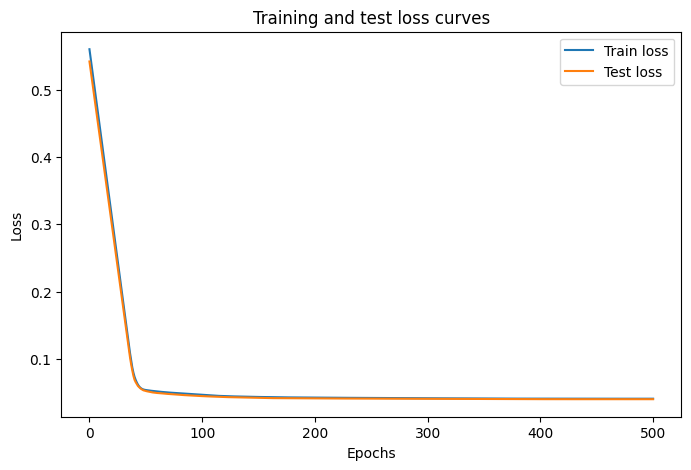

In [13]:
logs = np.array(logs)

# Plot the loss curves
plt.figure(figsize=(8, 5))
plt.plot(logs[:, 0], logs[:, 1], label="Train loss")
plt.plot(logs[:, 0], logs[:, 2], label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

### Test Trained Model

In [14]:
with torch.inference_mode():
  lr_model.eval()

  y_preds = lr_model(X_test)

  loss = loss_fn(y_preds, y_test)

  print(f"MAE Test Loss: {loss}")

MAE Test Loss: 0.039926927536726


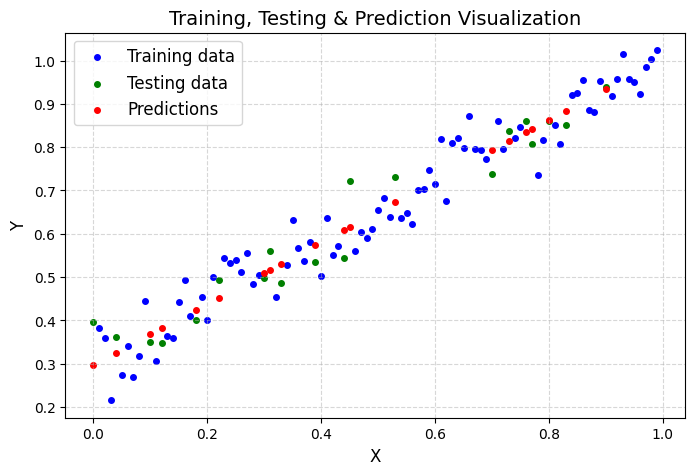

In [15]:
plot_predictions_compact(predictions=y_preds)